<span style="font-size: 22px; font-weight: bold;">The Evolution of Gaming</span>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
import seaborn as sns

In [16]:


# Connecting to MySQL
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)

cursor = conn.cursor()

# Ran query manually to inspect data
cursor.execute("SELECT * FROM dagevolve_full")
rows = cursor.fetchall()


columns = [col[0] for col in cursor.description]
df = pd.DataFrame(rows, columns=columns)

# Cleaned and converted North America_Sales
df["North America_Sales"] = (
    df["North America_Sales"]
    .replace(["", "N/A", "NA", None], 0)
    .astype(float)
    .fillna(0)
    .astype(int)
)

df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Nintendo Wii,2006,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
1,Super Mario Bros.,Nintendo NES,1985,Platform,Nintendo,Home,Nintendo,1983,2003,61.91,29,3.58,6.81,40.24
2,Mario Kart Wii,Nintendo Wii,2008,Racing,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
3,Wii Sports Resort,Nintendo Wii,2009,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41,29.02,3.77,82.74
4,Pokemon Red/Pokemon Blue,Gameboy,1996,Role-Playing,Nintendo,Handheld,Nintendo,1989,2003,64.42,11,8.89,10.22,31.37


In [17]:
query = """
SELECT 
    CAST(
        NULLIF(REPLACE(North_America_Sales, ',', ''), '') 
        AS UNSIGNED
    ) AS North_America_Sales,
    *
FROM dagevolve_full;
"""#    Execute the query and load results into a DataFrame

In [18]:
cursor.execute("SELECT * FROM dagevolve_full;")# 
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Wii Sports,Nintendo Wii,2006,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
1,Super Mario Bros.,Nintendo NES,1985,Platform,Nintendo,Home,Nintendo,1983,2003,61.91,29.08,3.58,6.81,40.24
2,Mario Kart Wii,Nintendo Wii,2008,Racing,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
3,Wii Sports Resort,Nintendo Wii,2009,Sports,Nintendo,Home,Nintendo,2006,2013,101.63,41.49,29.02,3.77,82.74
4,Pokemon Red/Pokemon Blue,Gameboy,1996,Role-Playing,Nintendo,Handheld,Nintendo,1989,2003,64.42,11.27,8.89,10.22,31.37


In [19]:
cursor.execute("DESCRIBE dagevolve_full;")
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])#  Inspect the structure of the GameSales table
df.head(15)

,Field,Type,Null,Key,Default,Extra
0,Game Title,text,YES,,None,
1,Console,varchar(50),YES,MUL,None,
2,Year,int,YES,,None,
3,Genre,text,YES,,None,
4,Game_Company,varchar(255),YES,,None,
5,Type,text,YES,,None,
6,Console_Company,text,YES,,None,
7,Console Release Year,int,YES,,None,
8,Console Disco Year,int,YES,,None,
9,Consoles sold (million),double,YES,,None,


In [20]:
import pandas as pd

cursor.execute("SELECT * FROM dagevolve_full ORDER BY Game_Company ASC;")# to get all the data from the GameSales table ordered by Genre in descending order
df = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])#
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


In [21]:
query = """
    SELECT Genre, Global_Sales
    FROM dagevolve_full
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]
genre_sales = pd.DataFrame(rows, columns=cols)


In [22]:
import pandas as pd

df_vgsales = pd.DataFrame(rows, columns=cols)
df_vgsales.head()


,Genre,Global_Sales
0,Sports,82.74
1,Platform,40.24
2,Racing,82.74
3,Sports,82.74
4,Role-Playing,31.37


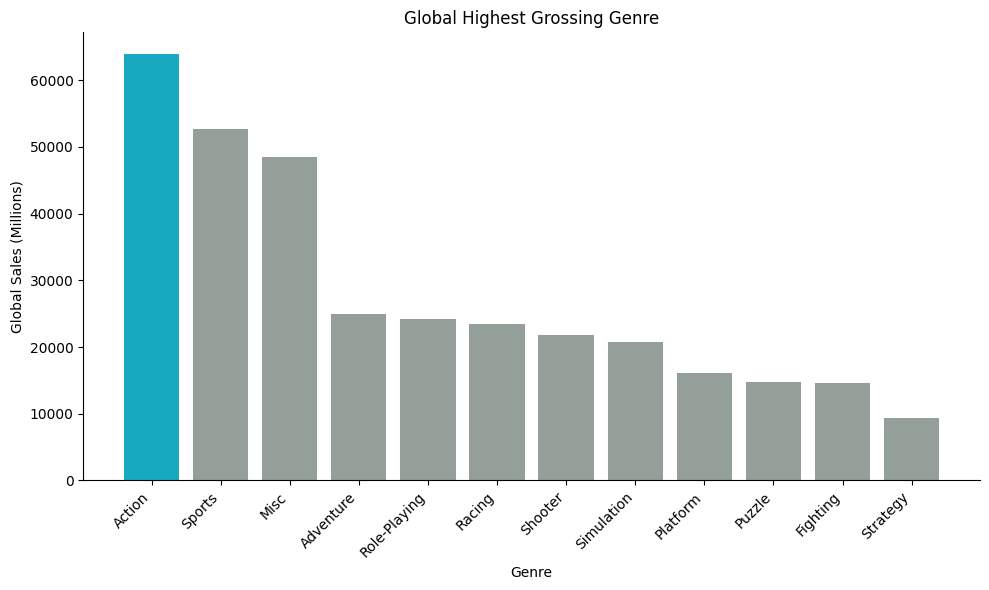

In [23]:
import matplotlib.pyplot as plt


Genre = df_vgsales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#959f99'] * len(Genre)

max_index = Genre.idxmax()
highlight_position = Genre.index.get_loc(max_index)
colors[highlight_position] = '#17a9bf'

plt.bar(Genre.index, Genre.values, color=colors, width=0.8)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.title("Global Highest Grossing Genre")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()




In [24]:
query = """
    SELECT Game_Company, Global_Sales
    FROM dagevolve_full
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
df_vgsales = pd.DataFrame(rows, columns=cols)
df.head()

,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


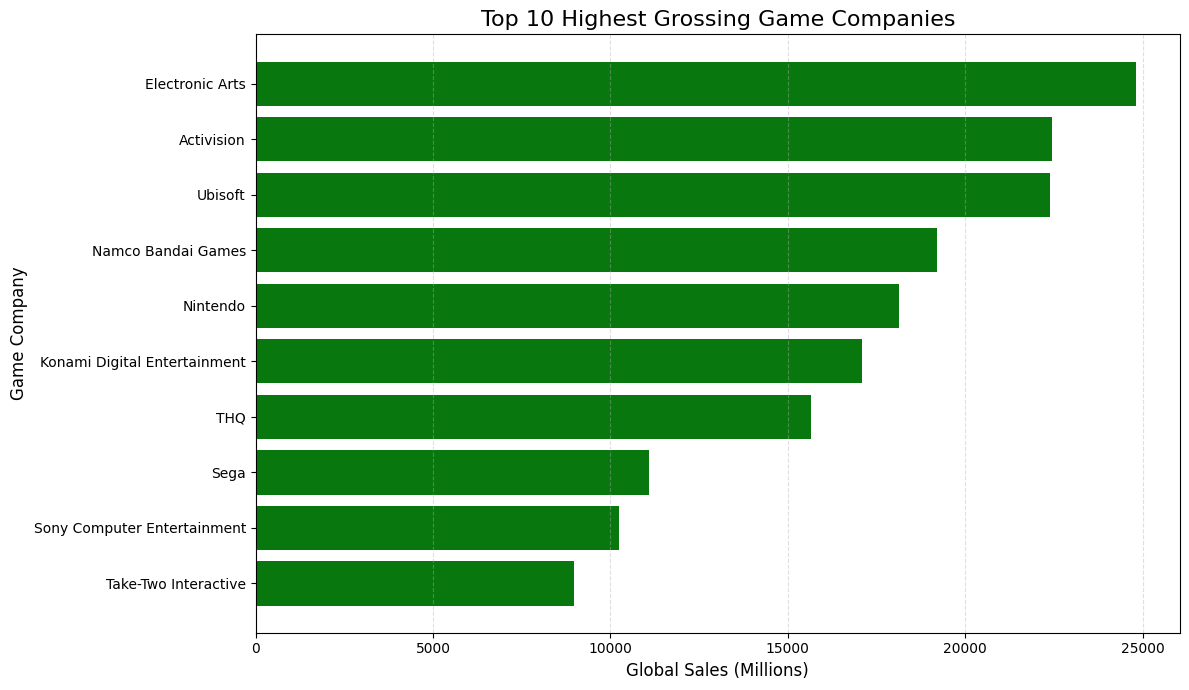

In [25]:
import matplotlib.pyplot as plt

Company_sales = (
    df_vgsales.groupby("Game_Company")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.barh(
    Company_sales["Game_Company"],
    Company_sales["Global_Sales"],
    color="#08770e"
)

plt.title("Top 10 Highest Grossing Game Companies", fontsize=16)
plt.xlabel("Global Sales (Millions)", fontsize=12)
plt.ylabel("Game Company", fontsize=12)

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [26]:
query = """
SELECT
    Console,
    Global_Sales,

    Japan_Sales,
    Europe_Sales
FROM dagevolve_full;
"""

cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

df_vgsales = pd.DataFrame(rows, columns=cols)
df.head()


,Game Title,Console,Year,Genre,Game_Company,Type,Console_Company,Console Release Year,Console Disco Year,Consoles sold (million),North America_Sales,Europe_Sales,Japan_Sales,Global_Sales
0,Pirates: Legend of the Black Buccaneer,PS2,2006,Adventure,10TACLE Studios,Home,Sony,2000,2013,155.00,9.43,0.40,0.41,20.81
1,Boulder Dash: Rocks!,Nintendo DS,2007,Puzzle,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
2,Panzer Tactics,Nintendo DS,2007,Strategy,10TACLE Studios,Handheld,Nintendo,2004,2013,154.02,11.38,9.23,6.50,30.01
3,Deadly Duck,Atari 2600,1981,Shooter,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81
4,Porky's,Atari 2600,1982,Action,20th Century Fox Video Games,Home,Atari,1977,1992,30.00,7.28,0.45,0.00,7.81


In [27]:
df = df.rename(columns={
    "North_America_Sales": "North America_Sales"
})


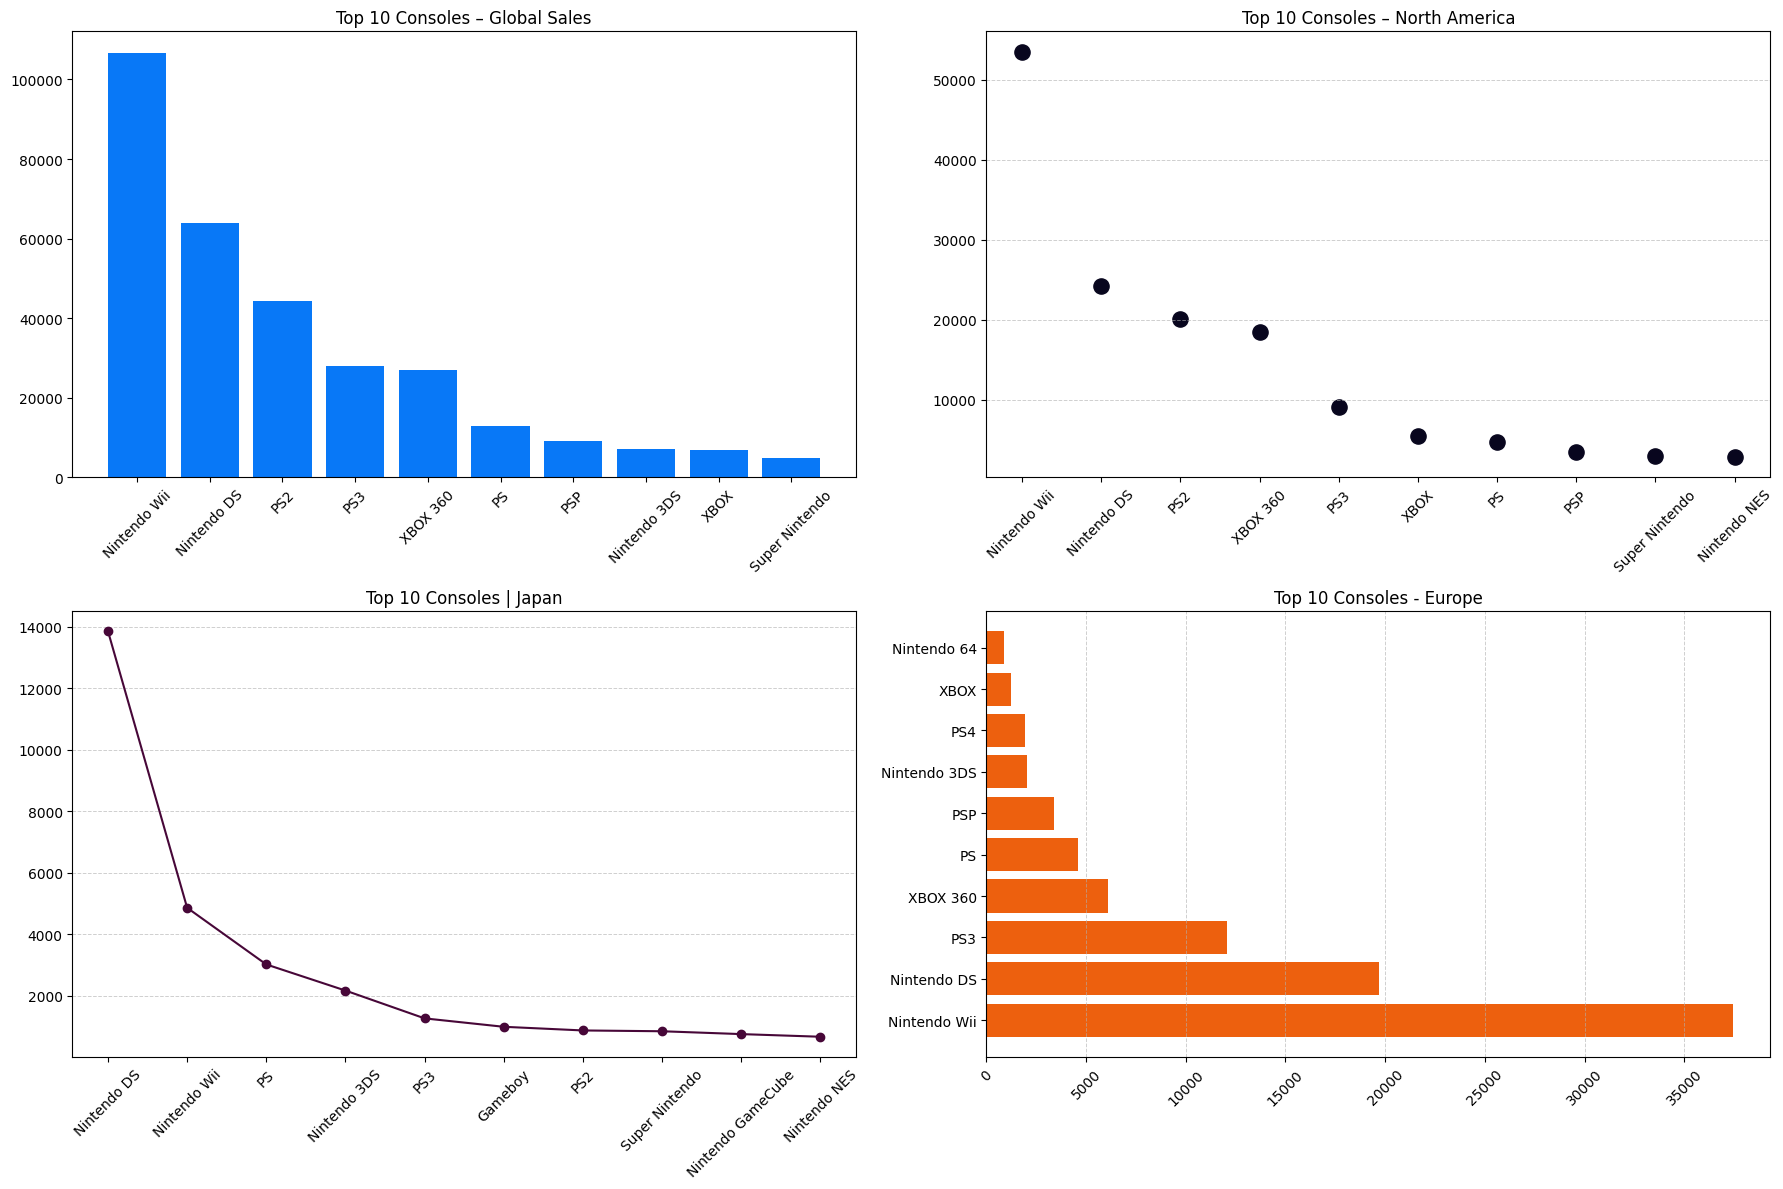

In [28]:
# Create top 10 for each region
na_sales = (
    df.groupby("Console")["North America_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

jp_sales = (
    df.groupby("Console")["Japan_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

eu_sales = (
    df.groupby("Console")["Europe_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

global_sales = (
    df.groupby("Console")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

stack_df = (
    na_sales[["Console", "North America_Sales"]]
    .merge(jp_sales[["Console", "Japan_Sales"]], on="Console", how="outer")
    .merge(eu_sales[["Console", "Europe_Sales"]], on="Console", how="outer")
    .merge(global_sales[["Console", "Global_Sales"]], on="Console", how="outer")
)

stack_df = stack_df.fillna(0).sort_values("Global_Sales", ascending=False)




# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- 1. Global: Bar Chart ---
axes[0, 0].bar(global_sales["Console"], global_sales["Global_Sales"], color="#0878F7")
axes[0, 0].set_title("Top 10 Consoles – Global Sales")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 1].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)

# --- 2. North America: Scatter Plot ---
axes[0, 1].scatter(na_sales["Console"], na_sales["North America_Sales"], color="#08061E", s=120)
axes[0, 1].set_title("Top 10 Consoles – North America")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)

# --- 3. Europe: Horizontal Bar Chart ---
axes[1, 1].barh( eu_sales["Console"], eu_sales["Europe_Sales"], color="#ED600E")
axes[1, 1].set_title("Top 10 Consoles - Europe")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].xaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)

# --- 4. Japan: Line Plot ---
axes[1, 0].plot(jp_sales["Console"], jp_sales["Japan_Sales"], marker="o", color="#470738")
axes[1, 0].set_title("Top 10 Consoles | Japan")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)




plt.tight_layout()
plt.show()



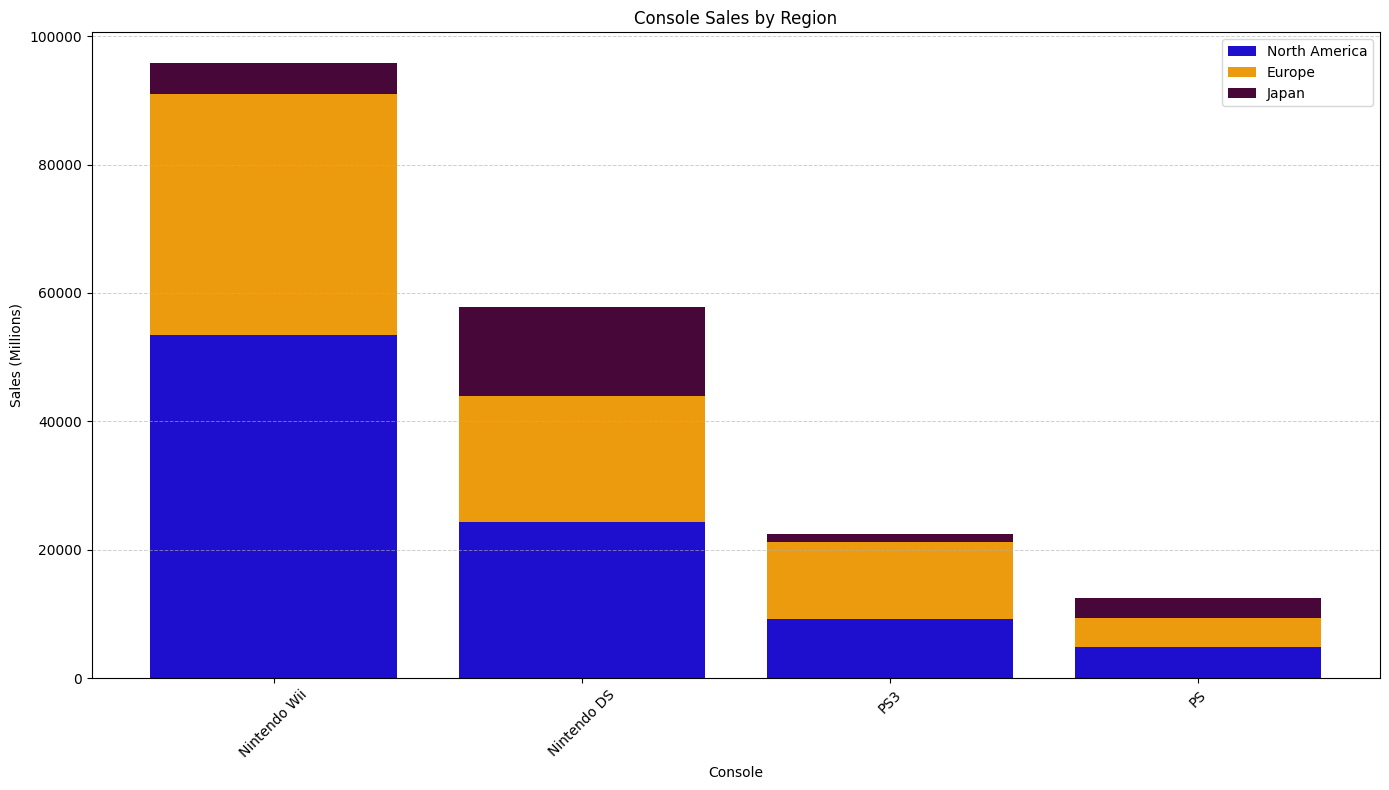

In [29]:
# Merge the three region DataFrames on Console
stack_df = (
    na_sales[["Console", "North America_Sales"]]
    .merge(eu_sales[["Console", "Europe_Sales"]], on="Console")
    .merge(jp_sales[["Console", "Japan_Sales"]], on="Console")
)

# Create stacked bar chart
plt.figure(figsize=(14, 8))

plt.bar(
    stack_df["Console"],
    stack_df["North America_Sales"],
    label="North America",
    color="#1E0ECD"
)

plt.bar(
    stack_df["Console"],
    stack_df["Europe_Sales"],
    bottom=stack_df["North America_Sales"],
    label="Europe",
    color="#ED9B0E"
)

plt.bar(
    stack_df["Console"],
    stack_df["Japan_Sales"],
    bottom=stack_df["North America_Sales"] + stack_df["Europe_Sales"],
    label="Japan",
    color="#470738"
)

plt.gca().yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.title("Console Sales by Region")
plt.xlabel("Console")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

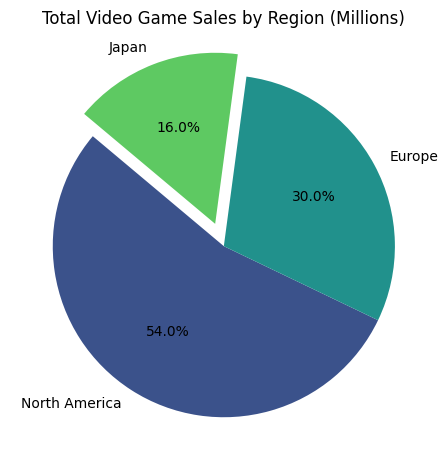

In [ ]:
query = """
SELECT 
    'North America' AS Region,
    SUM(`North America_Sales`) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Europe' AS Region,
    SUM(Europe_Sales) AS Total_Sales
FROM gamesales

UNION ALL

SELECT 
    'Japan' AS Region,
    SUM(Japan_Sales) AS Total_Sales
FROM gamesales;
"""
cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]
df_region_sales = pd.DataFrame(rows, columns=cols)

plt.pie(
    df_region_sales["Total_Sales"],
    labels=df_region_sales["Region"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(df_region_sales)),
    explode = [0, 0, 0.14]   # NA, EU, JP
    #explode = [
    #0.15 if v == df_region_sales["Total_Sales"].max() else 0
    #for v in df_region_sales["Total_Sales"]#  to explode the slice with the highest sales
    #]
    #explode = [0.05] * len(df_region_sales)   # explode all slices slightly

)



plt.title("Total Video Game Sales by Region (Millions)")
plt.tight_layout()
plt.show()


In [33]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Catalyst@312",
    database="dagevolve"
)

cursor = conn.cursor()

# Ran query manually to inspect data
cursor.execute("SELECT * FROM dagevolve_full")
rows = cursor.fetchall()


In [34]:
query = """
SELECT Game_Company, `Consoles sold (million)`
FROM dagevolve_full
"""

cursor.execute(query)
rows = cursor.fetchall()
cols = [col[0] for col in cursor.description]

import pandas as pd
df_vgsales = pd.DataFrame(rows, columns=cols)


In [35]:
top_companies = (
    df_vgsales.groupby("Game_Company")["Consoles sold (million)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_companies


,Game_Company,Consoles sold (million)
0,Electronic Arts,105494.70
1,Namco Bandai Games,86282.93
2,Activision,80282.61
3,Ubisoft,78947.38
4,Konami Digital Entertainment,77890.84
5,Sony Computer Entertainment,74081.72
6,THQ,58361.16
7,Nintendo,49464.33
8,Sega,45897.78
9,Take-Two Interactive,35258.06


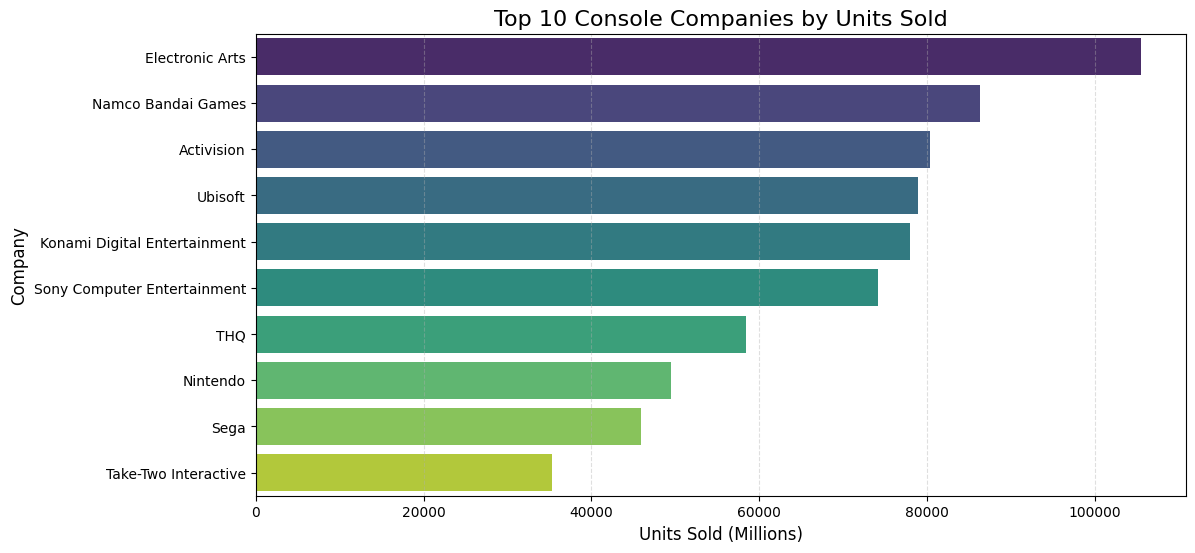

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_companies,
    x="Consoles sold (million)",
    y="Game_Company",
    hue="Game_Company",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Console Companies by Units Sold", fontsize=16)
plt.xlabel("Units Sold (Millions)", fontsize=12)
plt.ylabel("Company", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

